In [ ]:
from vvl.utils.volume_processing import volume_prep, pad_volume, skeletonize
from vvl.analysis import reconstruct_volume, load_volume
import matplotlib.pyplot as plt
import numpy as np
from vvl.utils.GraphInfo import GraphInfo
import igraph as ig
resolution = np.array([0.012, 0.012, 0.003])
resolution

In [11]:
vesselseg_path = r"C:\Users\go34nuy\data\Repro\test\processed\vessel_segmentation\R_CF_ER01_P1.nii.gz"
unfiltered_vol, _ = load_volume(vesselseg_path)
unfiltered_vol.shape

(328, 160, 278)

In [46]:
import networkx as nx
path = r"C:\Users\go34nuy\data\Repro\test\processed\vessel_segmentation\vesselvio\Graphs\R_CF_ER01_P1_lower.graphml"
lower_graph = nx.read_graphml(path)
lower_graph
path = r"C:\Users\go34nuy\data\Repro\test\processed\vessel_segmentation\vesselvio\Graphs\R_CF_ER01_P1_upper.graphml"
upper_graph = nx.read_graphml(path)
upper_graph
path = r"C:\Users\go34nuy\data\Repro\test\processed\vessel_segmentation\vesselvio\Graphs\R_CF_ER01_P1.graphml"
graph = nx.read_graphml(path)
graph



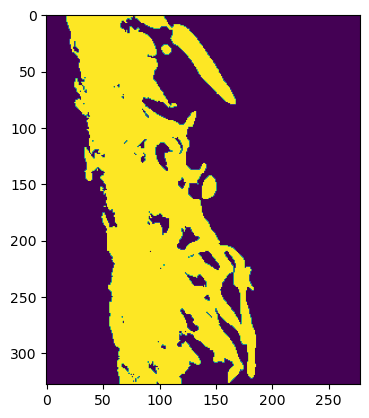

In [48]:
plt.imshow(unfiltered_vol.max(1));plt.show()

In [ ]:

def prune_igraph_upper_lower(self):
    lower_nodes, upper_nodes = set(), set()

    # classify edges and assign nodes
    for n1, n2, data in self.nx_graph.edges(data=True):
        locs = [self.vessel_depth_is_lower(x, y, z) 
                for x, y, z in data["original_edge_positions"]]
        is_lower = np.sum(locs) / len(locs)
        if is_lower:
            lower_nodes.update([n1, n2])
        else:
            upper_nodes.update([n1, n2])

    # node -> index lookup (assumes node names like "n0", "n1", ...)
    node_to_idx = {n: int(str(n).replace("n", "")) for n in self.nx_graph.nodes}

    # helper to build igraph subset
    def build_igraph(sub_nodes):
        idx = [node_to_idx[n] for n in sub_nodes]
        pts = self.points[idx]

        g = ig.Graph()
        g.add_vertices(len(pts))
        g.vs["v_coords"] = [tuple(p) for p in pts]
        g.vs["v_radius"] = [1.0] * len(pts)   # placeholder radii
        g.vs["vis_radius"] = [1.0] * len(pts)

        # add edges only if both endpoints are inside subset
        edges = [(node_to_idx[n1], node_to_idx[n2])
                 for n1, n2 in self.nx_graph.edges()
                 if n1 in sub_nodes and n2 in sub_nodes]
        g.add_edges(edges)

        return g

    self.lower_igraph = build_igraph(lower_nodes)
    self.upper_igraph = build_igraph(upper_nodes)


In [ ]:

volume, point_minima, point_maxima = volume_prep(unfiltered_vol)

volume = pad_volume(volume)
points = skeletonize(volume)

volume = volume[1:-1, 1:-1, 1:-1]
points -= 1


ig_lower = to_igraph(lower_graph)
ig_upper = to_igraph(upper_graph)

filtered_lower = reconstruct_volume(volume, ig_lower, points, resolution, point_minima)



# ig_graph = ig.Graph.from_networkx(graph)
# ig_graph.vs["v_coords"] = [
#     (float(v["Z"]), float(v["Y"]), float(v["X"]))
#     for v in ig_graph.vs
# ]

# filtered_lower = reconstruct_volume(volume, ig_graph, points, resolution, point_minima) >= 0



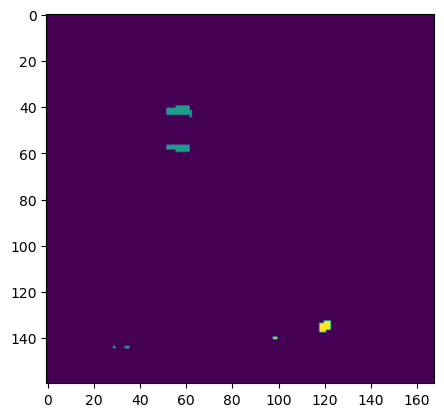

In [56]:
plt.imshow(filtered_lower.max(0));plt.show()